In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import re

# =========================
# 0. 基本設定
# =========================
poi_lat = 25.0190099143756
poi_lon = 121.53137177116402

# 你給的 GWL1.5 路徑（Windows 路徑請加 r）
tmean_folder = Path(r"\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_平均溫\GWL1.5")
tmax_folder  = Path(r"\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最高溫\GWL1.5")
tmin_folder  = Path(r"\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最低溫\GWL1.5")

INVALID_VALUE = -99.9

# 先指定同一模式
model_name = "ACCESS-CM2"

# 你目前要看的 SSP
target_ssps = ["ssp126", "ssp245", "ssp370", "ssp585"]


# =========================
# 1. 基本工具函式
# =========================
def get_files_for_model_and_ssp(folder: Path, model_name: str, ssp_name: str):
    """
    從 GWL1.5 資料夾內抓出某個 model + ssp 的所有 csv
    """
    files = sorted(folder.glob("*.csv"))
    matched = [
        f for f in files
        if (ssp_name in f.name) and (model_name in f.name)
    ]

    def extract_year_from_filename(fp):
        m = re.search(r"_(\d{4})\.csv$", fp.name)
        return int(m.group(1)) if m else -1

    matched = sorted(matched, key=extract_year_from_filename)
    return matched


def read_csv_with_fallback(csv_path: Path):
    """
    自動嘗試常見編碼
    """
    encodings = ["utf-8", "utf-8-sig", "big5"]
    last_error = None

    for enc in encodings:
        try:
            return pd.read_csv(csv_path, encoding=enc)
        except Exception as e:
            last_error = e

    raise last_error


def read_point_daily_series_from_csv(csv_path: Path, poi_lon: float, poi_lat: float):
    """
    適用 AR6 日資料格式：
    - 前兩欄：LON, LAT
    - 後面欄位：YYYYMMDD
    - 每列：一個格點
    """
    df = read_csv_with_fallback(csv_path)

    # 欄名標準化
    original_cols = list(df.columns)
    cols_upper = [str(c).upper() for c in df.columns]
    df.columns = cols_upper

    lon_col = df.columns[0]
    lat_col = df.columns[1]

    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")

    # 找最近格點
    dist = np.sqrt((df[lon_col] - poi_lon) ** 2 + (df[lat_col] - poi_lat) ** 2)
    idx = dist.idxmin()
    row = df.loc[idx]

    # 後面全是日期欄
    date_cols = df.columns[2:]
    dates = pd.to_datetime(date_cols, format="%Y%m%d", errors="coerce")
    values = pd.to_numeric(row[date_cols], errors="coerce").replace(INVALID_VALUE, np.nan)

    s = pd.Series(values.values, index=dates)
    s = s[~s.index.isna()].sort_index()

    return s, float(row[lon_col]), float(row[lat_col])


def load_full_daily_series(folder: Path, model_name: str, ssp_name: str, poi_lon: float, poi_lat: float):
    """
    把同一個 model + ssp 在 GWL1.5 資料夾中的所有年份檔案串成完整日序列
    """
    files = get_files_for_model_and_ssp(folder, model_name, ssp_name)
    if len(files) == 0:
        raise FileNotFoundError(f"{folder} 裡找不到 {ssp_name} + {model_name} 的檔案")

    series_list = []
    nearest_lon = None
    nearest_lat = None

    for f in files:
        s, lon0, lat0 = read_point_daily_series_from_csv(f, poi_lon, poi_lat)
        series_list.append(s)
        nearest_lon = lon0
        nearest_lat = lat0

    full = pd.concat(series_list, axis=0)
    full = full[~full.index.duplicated(keep="first")]
    full = full.sort_index()

    return full, nearest_lon, nearest_lat


# =========================
# 2. 月統計
# =========================
def calc_monthly_stats(tmean_series: pd.Series, tmax_series: pd.Series) -> pd.DataFrame:
    """
    先算月統計，後面再合季
    """
    df = pd.DataFrame({
        "tmean": tmean_series,
        "tmax": tmax_series
    }).dropna(subset=["tmean", "tmax"], how="all").sort_index()

    # 年月
    df["year"] = df.index.year
    df["month"] = df.index.month
    df["ym"] = df.index.to_period("M")

    monthly = df.groupby("ym").agg(
        tmean_monthly_mean=("tmean", "mean"),
        tmax_gt31_days=("tmax", lambda x: (x > 31).sum()),
        tmax_ge35_days=("tmax", lambda x: (x >= 35).sum()),
        tmax_ge40_days=("tmax", lambda x: (x >= 40).sum()),
        n_days=("tmax", "count"),
    )

    monthly["year"] = monthly.index.year
    monthly["month"] = monthly.index.month

    return monthly.reset_index(drop=False)


# =========================
# 3. 月轉季
# =========================
def month_to_season(month: int):
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    else:
        return "SON"


def assign_season_year(year: int, month: int):
    """
    DJF 讓 12 月歸到下一年的冬季
    例如 2030-12 算到 2031-DJF
    """
    if month == 12:
        return year + 1
    return year


def calc_seasonal_stats_from_monthly(monthly_df: pd.DataFrame) -> pd.DataFrame:
    df = monthly_df.copy()

    df["season"] = df["month"].apply(month_to_season)
    df["season_year"] = df.apply(lambda r: assign_season_year(int(r["year"]), int(r["month"])), axis=1)

    seasonal = df.groupby(["season_year", "season"]).agg(
        tmean_seasonal_mean=("tmean_monthly_mean", "mean"),
        tmax_gt31_days=("tmax_gt31_days", "sum"),
        tmax_ge35_days=("tmax_ge35_days", "sum"),
        tmax_ge40_days=("tmax_ge40_days", "sum"),
        n_days=("n_days", "sum"),
    ).reset_index()

    # 排序
    season_order = {"DJF": 1, "MAM": 2, "JJA": 3, "SON": 4}
    seasonal["season_order"] = seasonal["season"].map(season_order)
    seasonal = seasonal.sort_values(["season_year", "season_order"]).drop(columns="season_order")

    return seasonal


# =========================
# 4. 主流程：同一模式，不同 SSP
# =========================
monthly_results = {}
seasonal_results = {}
grid_info = {}

for ssp in target_ssps:
    try:
        tmean_series, lon0, lat0 = load_full_daily_series(
            tmean_folder, model_name, ssp, poi_lon, poi_lat
        )
        tmax_series, _, _ = load_full_daily_series(
            tmax_folder, model_name, ssp, poi_lon, poi_lat
        )

        monthly_df = calc_monthly_stats(tmean_series, tmax_series)
        seasonal_df = calc_seasonal_stats_from_monthly(monthly_df)

        monthly_results[ssp] = monthly_df
        seasonal_results[ssp] = seasonal_df
        grid_info[ssp] = {"lon": lon0, "lat": lat0}

        print(f"[OK] {model_name} | {ssp}")
        print(f"     nearest grid = ({lat0:.4f}, {lon0:.4f})")
        print(f"     monthly rows = {len(monthly_df)}, seasonal rows = {len(seasonal_df)}")

    except Exception as e:
        print(f"[SKIP] {model_name} | {ssp}: {e}")

[OK] ACCESS-CM2 | ssp126
     nearest grid = (25.0200, 121.5300)
     monthly rows = 240, seasonal rows = 81
[OK] ACCESS-CM2 | ssp245
     nearest grid = (25.0200, 121.5300)
     monthly rows = 240, seasonal rows = 81
[OK] ACCESS-CM2 | ssp370
     nearest grid = (25.0200, 121.5300)
     monthly rows = 240, seasonal rows = 81
[OK] ACCESS-CM2 | ssp585
     nearest grid = (25.0200, 121.5300)
     monthly rows = 240, seasonal rows = 81


In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from pathlib import Path

save_path = Path(r"\Users\user\OneDrive\桌面\Climate_project\程式作業\Daxue＿village\code")

ssp_order = ["ssp126", "ssp245", "ssp370", "ssp585"]
season_order = ["DJF", "MAM", "JJA", "SON"]

def build_seasonal_summary_table(seasonal_results, ssp_order=None, season_order=None):
    if ssp_order is None:
        ssp_order = sorted(seasonal_results.keys())
    if season_order is None:
        season_order = ["DJF", "MAM", "JJA", "SON"]

    summary = {}

    for ssp in ssp_order:
        sdf = seasonal_results[ssp].copy()

        tmp = (
            sdf.groupby("season")
            .agg(
                tmean_seasonal_mean=("tmean_seasonal_mean", "mean"),
                tmax_gt31_days=("tmax_gt31_days", "mean"),
                tmax_ge35_days=("tmax_ge35_days", "mean"),
                tmax_ge40_days=("tmax_ge40_days", "mean"),
            )
            .reindex(season_order)
        )

        summary[ssp] = tmp

    return summary


def plot_seasonal_bar_charts(seasonal_results, model_name, save_path=None):
    seasonal_summary = build_seasonal_summary_table(
        seasonal_results,
        ssp_order=ssp_order,
        season_order=season_order
    )

    metrics = [
        ("tmean_seasonal_mean", "Seasonal Mean Tmean", "°C"),
        ("tmax_gt31_days", "Seasonal Days with Tmax > 31°C", "Days"),
        ("tmax_ge35_days", "Seasonal Days with Tmax ≥ 35°C", "Days"),
        ("tmax_ge40_days", "Seasonal Days with Tmax ≥ 40°C", "Days"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    x = np.arange(len(season_order))
    width = 0.18

    colors = {
        "ssp126": "#1f77b4",
        "ssp245": "#2ca02c",
        "ssp370": "#ff7f0e",
        "ssp585": "#d62728",
    }

    for ax, (metric, title, ylabel) in zip(axes, metrics):
        for i, ssp in enumerate(ssp_order):
            vals = seasonal_summary[ssp][metric].values
            ax.bar(
                x + (i - 1.5) * width,
                vals,
                width=width,
                label=ssp,
                color=colors.get(ssp, None),
                alpha=0.85
            )

        ax.set_xticks(x)
        ax.set_xticklabels(season_order)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(axis="y", alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4)
    fig.suptitle(f"Daxue_village - {model_name} Seasonal Cockroach Thermal Metrics", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path is not None:
        from pathlib import Path
        save_path = Path(save_path)
        filename = f"Daxue_village_{model_name}_Seasonal_Cockroach_Thermal_Metrics.png"
        plt.savefig(save_path / filename, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_path / filename}")

    plt.show()

In [29]:
def build_monthly_threshold_climatology(monthly_results, ssp_order=None):
    if ssp_order is None:
        ssp_order = sorted(monthly_results.keys())

    climatology = {}

    for ssp in ssp_order:
        mdf = monthly_results[ssp].copy()

        tmp = (
            mdf.groupby("month")
            .agg(
                tmax_gt31_days=("tmax_gt31_days", "mean"),
                tmax_ge35_days=("tmax_ge35_days", "mean"),
                tmax_ge40_days=("tmax_ge40_days", "mean"),
            )
            .reindex(range(1, 13))
        )

        climatology[ssp] = tmp

    return climatology


def plot_monthly_threshold_lines(monthly_results, model_name, save_path=None):
    monthly_clim = build_monthly_threshold_climatology(
        monthly_results,
        ssp_order=ssp_order
    )

    metrics = [
        ("tmax_gt31_days", "Monthly Mean Days with Tmax > 31°C", "Days / Month"),
        ("tmax_ge35_days", "Monthly Mean Days with Tmax ≥ 35°C", "Days / Month"),
        ("tmax_ge40_days", "Monthly Mean Days with Tmax ≥ 40°C", "Days / Month"),
    ]

    colors = {
        "ssp126": "#1f77b4",
        "ssp245": "#2ca02c",
        "ssp370": "#ff7f0e",
        "ssp585": "#d62728",
    }

    month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

    for ax, (metric, title, ylabel) in zip(axes, metrics):
        for ssp in ssp_order:
            vals = monthly_clim[ssp][metric].values

            ax.plot(
                range(1, 13),
                vals,
                marker="o",
                linewidth=2,
                label=ssp,
                color=colors.get(ssp, None)
            )

        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

    axes[-1].set_xticks(range(1, 13))
    axes[-1].set_xticklabels(month_labels)
    axes[0].legend(ncol=4, loc="lower center")

    fig.suptitle(f"Daxue_village - {model_name} Monthly Cockroach Heat Threshold Days", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_path is not None:
        from pathlib import Path
        save_path = Path(save_path)
        filename = f"Daxue_village_{model_name}_Monthly_Cockroach_Heat_Threshold_Days.png"
        plt.savefig(save_path / filename, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_path / filename}")

    plt.show()

✅ Saved: \Users\user\OneDrive\桌面\Climate_project\程式作業\Daxue＿village\code\Daxue_village_ACCESS-CM2_Seasonal_Cockroach_Thermal_Metrics.png


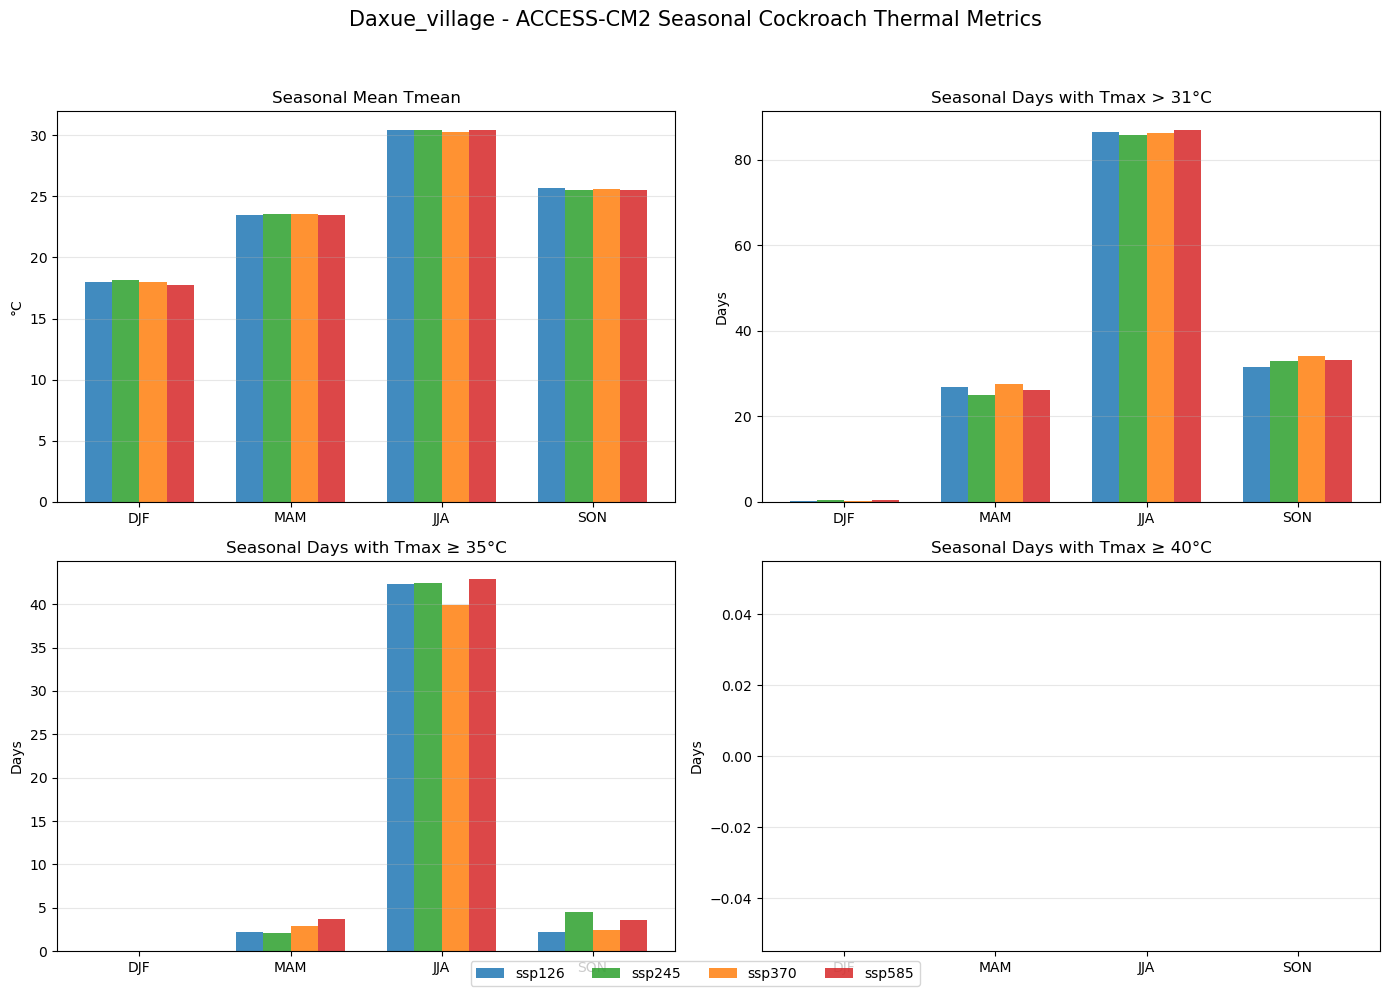

In [30]:
plot_seasonal_bar_charts(
    seasonal_results=seasonal_results,
    model_name=model_name,
    save_path=save_path
)

✅ Saved: \Users\user\OneDrive\桌面\Climate_project\程式作業\Daxue＿village\code\Daxue_village_ACCESS-CM2_Monthly_Cockroach_Heat_Threshold_Days.png


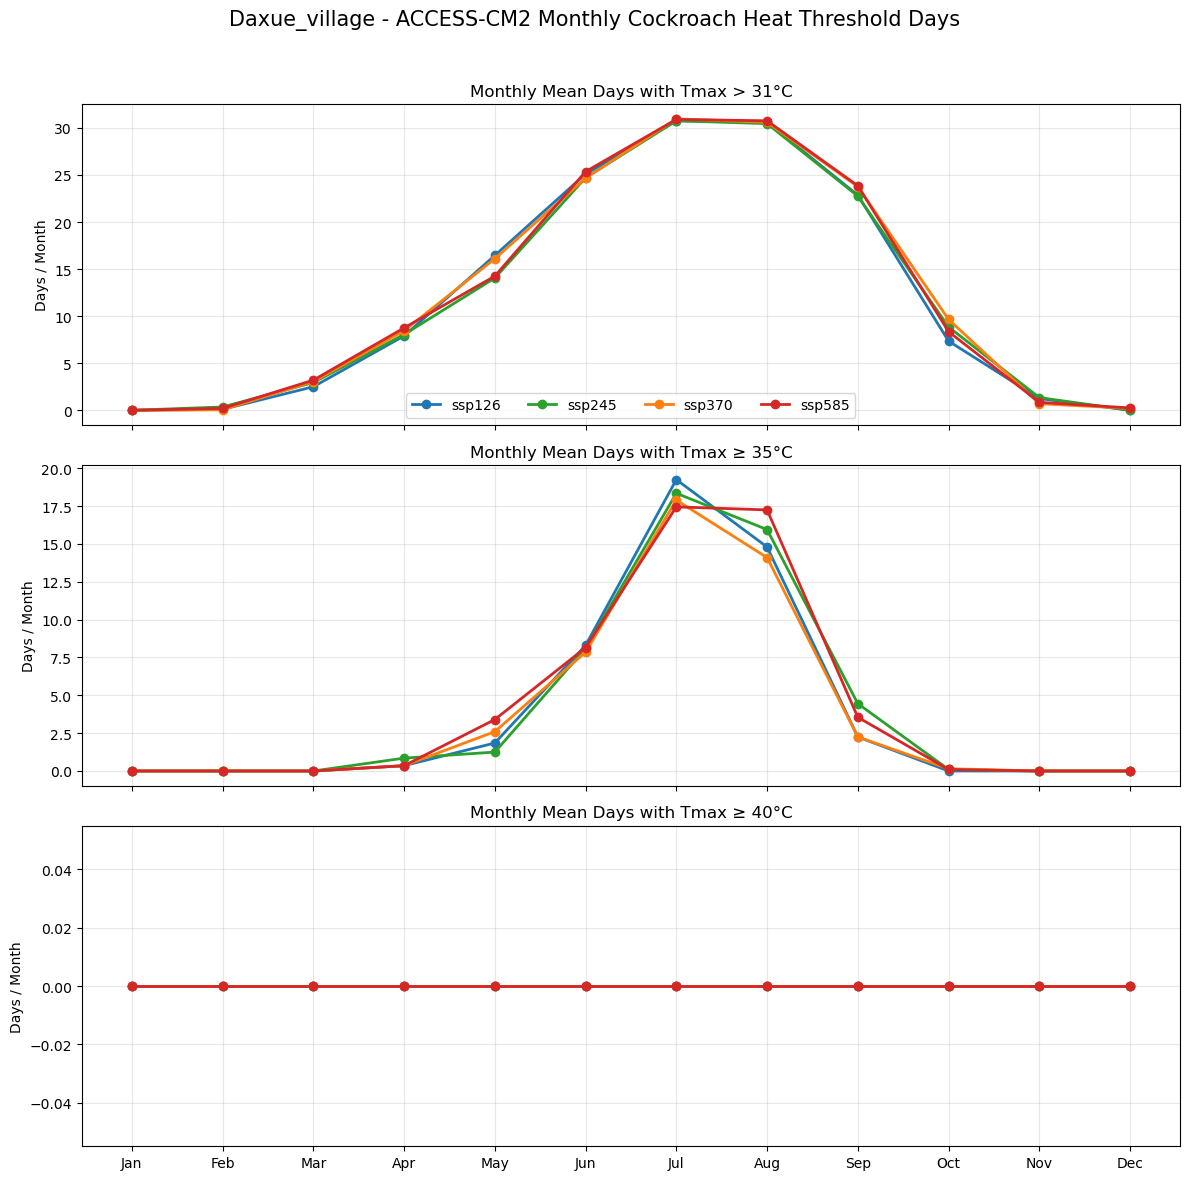

In [31]:
plot_monthly_threshold_lines(
    monthly_results=monthly_results,
    model_name=model_name,
    save_path=save_path
)

[OK] TaiESM1 | ssp126
     nearest grid = (25.0200, 121.5300)
     monthly rows = 180, seasonal rows = 61
[OK] TaiESM1 | ssp245
     nearest grid = (25.0200, 121.5300)
     monthly rows = 156, seasonal rows = 53
[OK] TaiESM1 | ssp370
     nearest grid = (25.0200, 121.5300)
     monthly rows = 132, seasonal rows = 45
[OK] TaiESM1 | ssp585
     nearest grid = (25.0200, 121.5300)
     monthly rows = 180, seasonal rows = 61


C:\Users\user\AppData\Local\Temp\ipykernel_23864\3883964809.py:262: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdf.groupby("season")
C:\Users\user\AppData\Local\Temp\ipykernel_23864\3883964809.py:262: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdf.groupby("season")
C:\Users\user\AppData\Local\Temp\ipykernel_23864\3883964809.py:262: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdf.groupby("season")
C:\Users\user\Ap

✅ Saved: \Users\user\OneDrive\桌面\Climate_project\程式作業\Daxue＿village\code\Daxue_village_TaiESM1_Seasonal_Cockroach_Thermal_Metrics_2020_2034.png


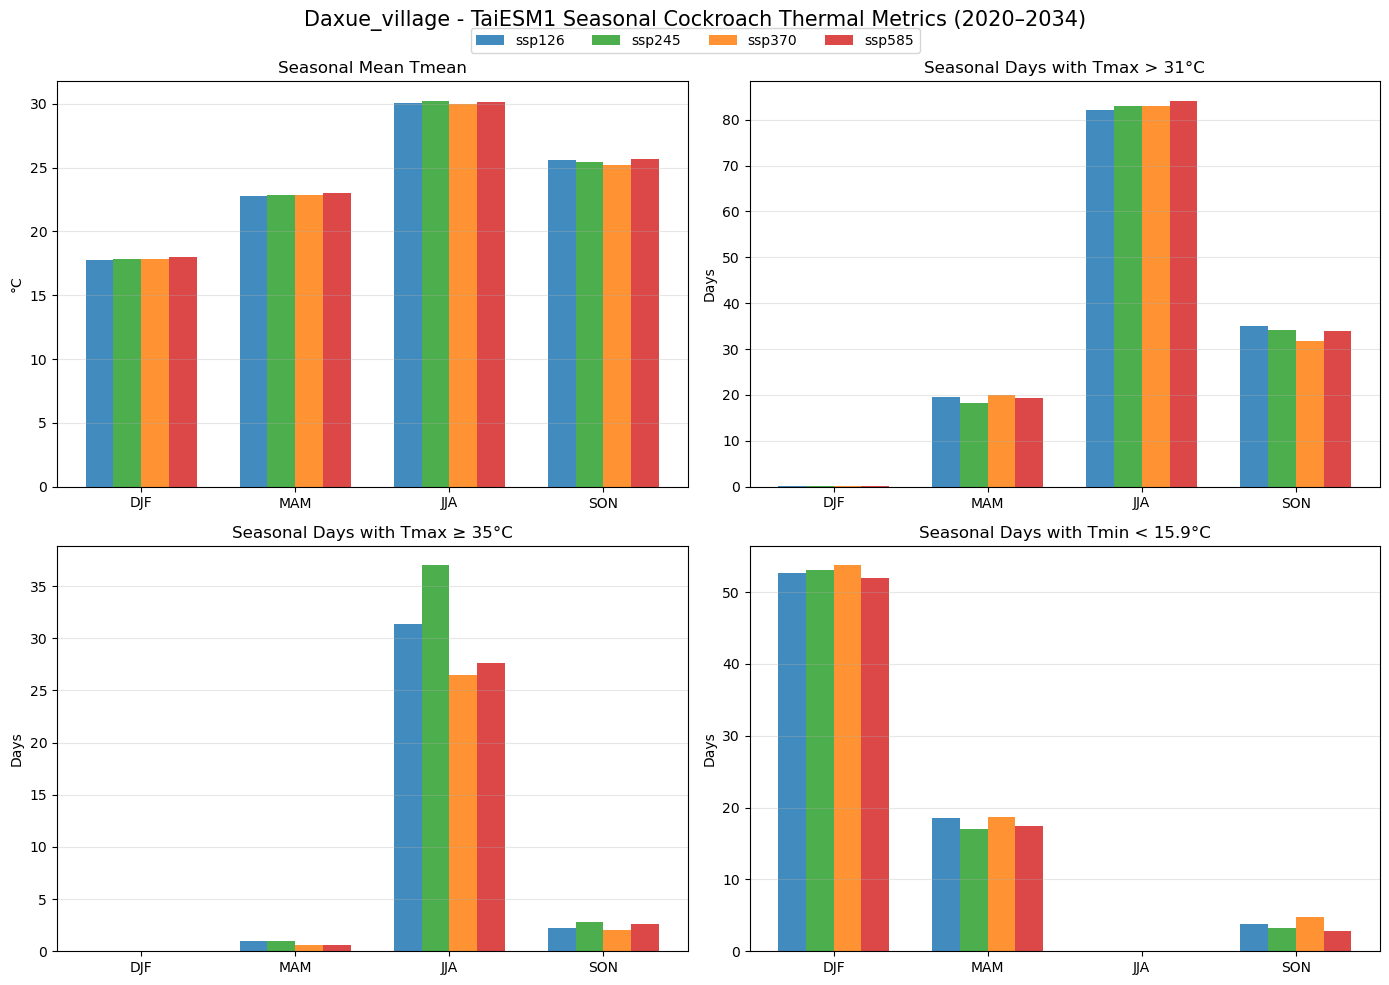

✅ Saved: \Users\user\OneDrive\桌面\Climate_project\程式作業\Daxue＿village\code\Daxue_village_TaiESM1_Monthly_Cockroach_Thermal_Threshold_Days_2020_2034.png


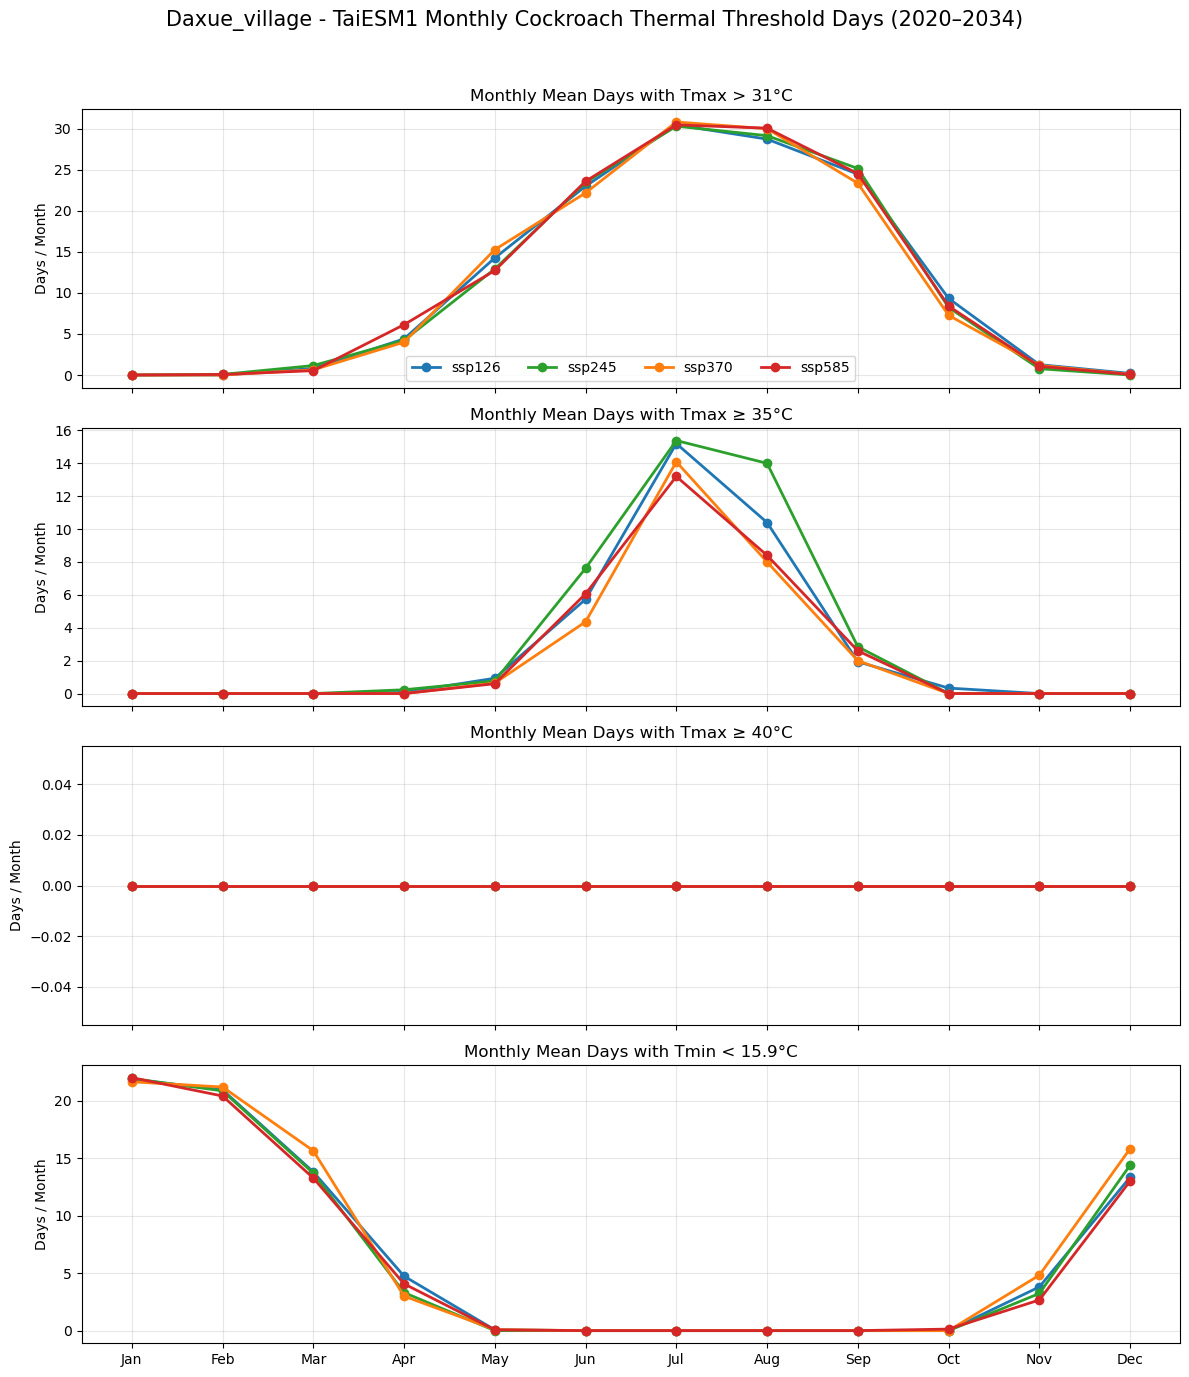

In [75]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# =========================================================
# 0. 基本設定
# =========================================================
poi_lat = 25.0190099143756
poi_lon = 121.53137177116402

# 你的資料路徑（Windows 建議用 raw string）
tmean_folder = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_平均溫\GWL1.5")
tmax_folder  = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最高溫\GWL1.5")
tmin_folder  = Path(r"C:\Users\user\OneDrive\桌面\climate_project_old\程式作業\AR6_統計降尺度_日資料_臺北市_最低溫\GWL1.5")

# 圖片輸出路徑
save_path = Path(r"\Users\user\OneDrive\桌面\Climate_project\程式作業\Daxue＿village\code")
save_path.mkdir(parents=True, exist_ok=True)

# 分析模式
model_name = "TaiESM1"  # ["TaiESM1", "ACCESS-CM2", "EC-Earth3"]

# 分析 SSP
target_ssps = ["ssp126", "ssp245", "ssp370", "ssp585"]

# 年份限制
start_year = 2020
end_year = 2034

INVALID_VALUE = -99.9

ssp_colors = {
    "ssp126": "#1f77b4",  # blue
    "ssp245": "#2ca02c",  # green
    "ssp370": "#ff7f0e",  # orange
    "ssp585": "#d62728",  # red
}

season_order = ["DJF", "MAM", "JJA", "SON"]


# =========================================================
# 1. 讀檔工具
# =========================================================
def read_csv_with_fallback(csv_path: Path):
    encodings = ["utf-8", "utf-8-sig", "big5"]
    last_error = None

    for enc in encodings:
        try:
            return pd.read_csv(csv_path, encoding=enc)
        except Exception as e:
            last_error = e

    raise last_error


def extract_year_from_filename(fp: Path):
    m = re.search(r"_(\d{4})\.csv$", fp.name)
    return int(m.group(1)) if m else -1


def get_files_for_model_and_ssp(folder: Path, model_name: str, ssp_name: str):
    files = sorted(folder.glob("*.csv"))
    matched = [
        f for f in files
        if (ssp_name in f.name) and (model_name in f.name)
    ]
    matched = sorted(matched, key=extract_year_from_filename)
    return matched


def read_point_daily_series_from_csv(csv_path: Path, poi_lon: float, poi_lat: float):
    """
    適用格式：
    LON | LAT | 20200101 | 20200102 | ...
    """
    df = read_csv_with_fallback(csv_path)

    cols_upper = [str(c).upper() for c in df.columns]
    df.columns = cols_upper

    lon_col = df.columns[0]
    lat_col = df.columns[1]

    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")

    # 找最近格點
    dist = np.sqrt((df[lon_col] - poi_lon) ** 2 + (df[lat_col] - poi_lat) ** 2)
    idx = dist.idxmin()
    row = df.loc[idx]

    date_cols = df.columns[2:]
    dates = pd.to_datetime(date_cols, format="%Y%m%d", errors="coerce")
    values = pd.to_numeric(row[date_cols], errors="coerce").replace(INVALID_VALUE, np.nan)

    s = pd.Series(values.values, index=dates)
    s = s[~s.index.isna()].sort_index()

    return s, float(row[lon_col]), float(row[lat_col])


def load_full_daily_series(folder: Path, model_name: str, ssp_name: str, poi_lon: float, poi_lat: float):
    files = get_files_for_model_and_ssp(folder, model_name, ssp_name)
    if len(files) == 0:
        raise FileNotFoundError(f"{folder} 裡找不到 {ssp_name} + {model_name} 的檔案")

    series_list = []
    nearest_lon = None
    nearest_lat = None

    for f in files:
        s, lon0, lat0 = read_point_daily_series_from_csv(f, poi_lon, poi_lat)
        series_list.append(s)
        nearest_lon = lon0
        nearest_lat = lat0

    full = pd.concat(series_list, axis=0)
    full = full[~full.index.duplicated(keep="first")]
    full = full.sort_index()

    return full, nearest_lon, nearest_lat


# =========================================================
# 2. 月統計與季統計
# =========================================================
def calc_monthly_stats(tmean_series, tmax_series, tmin_series):
    df = pd.DataFrame({
        "tmean": tmean_series,
        "tmax": tmax_series,
        "tmin": tmin_series
    }).dropna(how="all").sort_index()

    # 限制年份
    df = df[(df.index.year >= start_year) & (df.index.year <= end_year)].copy()

    df["year"] = df.index.year
    df["month"] = df.index.month
    df["ym"] = df.index.to_period("M")

    monthly = df.groupby("ym").agg(
        # 平均溫
        tmean_monthly_mean=("tmean", "mean"),

        # 高溫條件
        tmax_gt31_days=("tmax", lambda x: (x > 31).sum()),
        tmax_ge35_days=("tmax", lambda x: (x >= 35).sum()),
        tmax_ge40_days=("tmax", lambda x: (x >= 40).sum()),

        # 冷壓力
        tmin_lt15_9_days=("tmin", lambda x: (x < 15.9).sum()),

        n_days=("tmean", "count"),
    )

    monthly["year"] = monthly.index.year
    monthly["month"] = monthly.index.month

    return monthly.reset_index(drop=False)


def month_to_season(month):
    if month in [12, 1, 2]:
        return "DJF"
    elif month in [3, 4, 5]:
        return "MAM"
    elif month in [6, 7, 8]:
        return "JJA"
    else:
        return "SON"


def assign_season_year(year, month):
    # 12 月歸到下一年冬季
    if month == 12:
        return year + 1
    return year


def calc_seasonal_stats_from_monthly(monthly_df):
    df = monthly_df.copy()

    df["season"] = df["month"].apply(month_to_season)
    df["season_year"] = df.apply(
        lambda r: assign_season_year(int(r["year"]), int(r["month"])),
        axis=1
    )

    seasonal = df.groupby(["season_year", "season"]).agg(
        tmean_seasonal_mean=("tmean_monthly_mean", "mean"),
        tmax_gt31_days=("tmax_gt31_days", "sum"),
        tmax_ge35_days=("tmax_ge35_days", "sum"),
        tmax_ge40_days=("tmax_ge40_days", "sum"),
        tmin_lt15_9_days=("tmin_lt15_9_days", "sum"),
        n_days=("n_days", "sum"),
    ).reset_index()

    seasonal["season"] = pd.Categorical(seasonal["season"], categories=season_order, ordered=True)
    seasonal = seasonal.sort_values(["season_year", "season"])

    return seasonal


# =========================================================
# 3. 主流程：同一模式，不同 SSP
# =========================================================
monthly_results = {}
seasonal_results = {}
grid_info = {}

for ssp in target_ssps:
    try:
        tmean_series, lon0, lat0 = load_full_daily_series(
            tmean_folder, model_name, ssp, poi_lon, poi_lat
        )
        tmax_series, _, _ = load_full_daily_series(
            tmax_folder, model_name, ssp, poi_lon, poi_lat
        )
        tmin_series, _, _ = load_full_daily_series(
            tmin_folder, model_name, ssp, poi_lon, poi_lat
        )

        # 限制年份
        tmean_series = tmean_series[f"{start_year}":f"{end_year}"]
        tmax_series  = tmax_series[f"{start_year}":f"{end_year}"]
        tmin_series  = tmin_series[f"{start_year}":f"{end_year}"]

        monthly_df = calc_monthly_stats(tmean_series, tmax_series, tmin_series)
        seasonal_df = calc_seasonal_stats_from_monthly(monthly_df)

        monthly_results[ssp] = monthly_df
        seasonal_results[ssp] = seasonal_df
        grid_info[ssp] = {"lon": lon0, "lat": lat0}

        print(f"[OK] {model_name} | {ssp}")
        print(f"     nearest grid = ({lat0:.4f}, {lon0:.4f})")
        print(f"     monthly rows = {len(monthly_df)}, seasonal rows = {len(seasonal_df)}")

    except Exception as e:
        print(f"[SKIP] {model_name} | {ssp}: {e}")


# =========================================================
# 4. 季節摘要表
# =========================================================
def build_seasonal_summary_table(seasonal_results, ssp_order=None, season_order=None):
    if ssp_order is None:
        ssp_order = sorted(seasonal_results.keys())
    if season_order is None:
        season_order = ["DJF", "MAM", "JJA", "SON"]

    summary = {}

    for ssp in ssp_order:
        sdf = seasonal_results[ssp].copy()

        tmp = (
            sdf.groupby("season")
            .agg(
                tmean_seasonal_mean=("tmean_seasonal_mean", "mean"),
                tmax_gt31_days=("tmax_gt31_days", "mean"),
                tmax_ge35_days=("tmax_ge35_days", "mean"),
                tmax_ge40_days=("tmax_ge40_days", "mean"),
                tmin_lt15_9_days=("tmin_lt15_9_days", "mean"),
            )
            .reindex(season_order)
        )

        summary[ssp] = tmp

    return summary


# =========================================================
# 5. 圖 1：季節長條圖
# =========================================================
def plot_seasonal_bar_charts(seasonal_results, model_name, save_path=None):
    seasonal_summary = build_seasonal_summary_table(
        seasonal_results,
        ssp_order=target_ssps,
        season_order=season_order
    )

    metrics = [
        ("tmean_seasonal_mean", "Seasonal Mean Tmean", "°C"),
        ("tmax_gt31_days", "Seasonal Days with Tmax > 31°C", "Days"),
        ("tmax_ge35_days", "Seasonal Days with Tmax ≥ 35°C", "Days"),
        ("tmin_lt15_9_days", "Seasonal Days with Tmin < 15.9°C", "Days"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    x = np.arange(len(season_order))
    width = 0.18

    for ax, (metric, title, ylabel) in zip(axes, metrics):
        for i, ssp in enumerate(target_ssps):
            vals = seasonal_summary[ssp][metric].values
            ax.bar(
                x + (i - 1.5) * width,
                vals,
                width=width,
                label=ssp,
                color=ssp_colors.get(ssp, None),
                alpha=0.85
            )

        ax.set_xticks(x)
        ax.set_xticklabels(season_order)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(axis="y", alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4,bbox_to_anchor=(0.5, 0.93))
    fig.suptitle(f"Daxue_village - {model_name} Seasonal Cockroach Thermal Metrics (2020–2034)", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        filename = f"Daxue_village_{model_name}_Seasonal_Cockroach_Thermal_Metrics_2020_2034.png"
        save_file = save_path / filename
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()


# =========================================================
# 6. 圖 2：每月閾值折線圖
# =========================================================
def build_monthly_threshold_climatology(monthly_results, ssp_order=None):
    if ssp_order is None:
        ssp_order = sorted(monthly_results.keys())

    climatology = {}

    for ssp in ssp_order:
        mdf = monthly_results[ssp].copy()

        tmp = (
            mdf.groupby("month")
            .agg(
                tmax_gt31_days=("tmax_gt31_days", "mean"),
                tmax_ge35_days=("tmax_ge35_days", "mean"),
                tmax_ge40_days=("tmax_ge40_days", "mean"),
                tmin_lt15_9_days=("tmin_lt15_9_days", "mean"),
            )
            .reindex(range(1, 13))
        )

        climatology[ssp] = tmp

    return climatology


def plot_monthly_threshold_lines(monthly_results, model_name, save_path=None):
    monthly_clim = build_monthly_threshold_climatology(
        monthly_results,
        ssp_order=target_ssps
    )

    metrics = [
        ("tmax_gt31_days", "Monthly Mean Days with Tmax > 31°C", "Days / Month"),
        ("tmax_ge35_days", "Monthly Mean Days with Tmax ≥ 35°C", "Days / Month"),
        ("tmax_ge40_days", "Monthly Mean Days with Tmax ≥ 40°C", "Days / Month"),
        ("tmin_lt15_9_days", "Monthly Mean Days with Tmin < 15.9°C", "Days / Month"),
    ]

    month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

    for ax, (metric, title, ylabel) in zip(axes, metrics):
        for ssp in target_ssps:
            vals = monthly_clim[ssp][metric].values

            ax.plot(
                range(1, 13),
                vals,
                marker="o",
                linewidth=2,
                label=ssp,
                color=ssp_colors.get(ssp, None)
            )

        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

    axes[-1].set_xticks(range(1, 13))
    axes[-1].set_xticklabels(month_labels)
    axes[0].legend(ncol=4, loc="lower center")

    fig.suptitle(f"Daxue_village - {model_name} Monthly Cockroach Thermal Threshold Days (2020–2034)", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_path is not None:
        filename = f"Daxue_village_{model_name}_Monthly_Cockroach_Thermal_Threshold_Days_2020_2034.png"
        save_file = save_path / filename
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()


# =========================================================
# 7. 輸出表格 + 畫圖
# =========================================================
# 先看一個 SSP 的月資料 / 季資料
# print(monthly_results["ssp245"].head())
# print(seasonal_results["ssp245"].head())

plot_seasonal_bar_charts(
    seasonal_results=seasonal_results,
    model_name=model_name,
    save_path=save_path
)

plot_monthly_threshold_lines(
    monthly_results=monthly_results,
    model_name=model_name,
    save_path=save_path
)

In [44]:
def safe_filename(text):
    return (
        text
        .replace(" ", "_")
        .replace(">", "gt")
        .replace("<", "lt")
        .replace("=", "eq")
        .replace("°", "")
    )
    

In [46]:
title = "Seasonal Days with Tmax > 31C"
safe_title = safe_filename(title)

In [76]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

season_order = ["DJF", "MAM", "JJA", "SON"]

ssp_colors = {
    "ssp126": "#1f77b4",
    "ssp245": "#2ca02c",
    "ssp370": "#ff7f0e",
    "ssp585": "#d62728",
}

def plot_seasonal_interannual_timeseries(
    seasonal_results,
    metric,
    title,
    ylabel,
    model_name,
    save_path=None,
    ylim=None
):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    axes = axes.flatten()

    for i, season in enumerate(season_order):
        ax = axes[i]

        for ssp in target_ssps:
            if ssp not in seasonal_results:
                continue

            sdf = seasonal_results[ssp].copy()
            sub = sdf[sdf["season"] == season].copy()

            # 限制年份
            sub = sub[(sub["season_year"] >= start_year) & (sub["season_year"] <= end_year)]

            if len(sub) == 0:
                continue

            ax.plot(
                sub["season_year"],
                sub[metric],
                marker="o",
                linewidth=2,
                label=ssp,
                color=ssp_colors.get(ssp, None)
            )

        ax.set_title(season)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

        if ylim is not None:
            ax.set_ylim(ylim)

        xticks = np.arange(start_year, end_year + 1, 2)
        ax.set_xticks(xticks)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4,bbox_to_anchor=(0.5, 0.90))
    fig.suptitle(f"Daxue_village - {model_name} {title} (2020–2034)", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        save_file = Path(save_path) / f"Daxue_village_{model_name}_{title.replace(' ', '_')}_2020_2034.png"
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()

In [77]:
def plot_ssp_interannual_by_season(
    seasonal_results,
    metric,
    title,
    ylabel,
    model_name,
    save_path=None,
    ylim=None
):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    axes = axes.flatten()

    season_colors = {
        "DJF": "#1f77b4",
        "MAM": "#2ca02c",
        "JJA": "#d62728",
        "SON": "#ff7f0e",
    }

    for i, ssp in enumerate(target_ssps):
        ax = axes[i]

        if ssp not in seasonal_results:
            continue

        sdf = seasonal_results[ssp].copy()
        sdf = sdf[(sdf["season_year"] >= start_year) & (sdf["season_year"] <= end_year)]

        for season in season_order:
            sub = sdf[sdf["season"] == season].copy()
            if len(sub) == 0:
                continue

            ax.plot(
                sub["season_year"],
                sub[metric],
                marker="o",
                linewidth=2,
                label=season,
                color=season_colors.get(season, None)
            )

        ax.set_title(ssp)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

        if ylim is not None:
            ax.set_ylim(ylim)

        xticks = np.arange(start_year, end_year + 1, 2)
        ax.set_xticks(xticks)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4,bbox_to_anchor=(0.5, 0.90))
    fig.suptitle(f"Daxue_village - {model_name} {title} (2020–2034)", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        save_file = Path(save_path) / f"Daxue_village_{model_name}_{title.replace(' ', '_')}_bySSP_2020_2034.png"
        plt.savefig(save_file, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_file}")

    plt.show()

✅ Saved: \Users\user\OneDrive\桌面\Climate_project\程式作業\Daxue＿village\code\Daxue_village_TaiESM1_Seasonal_Mean_Tmean_Interannual_Variation_2020_2034.png


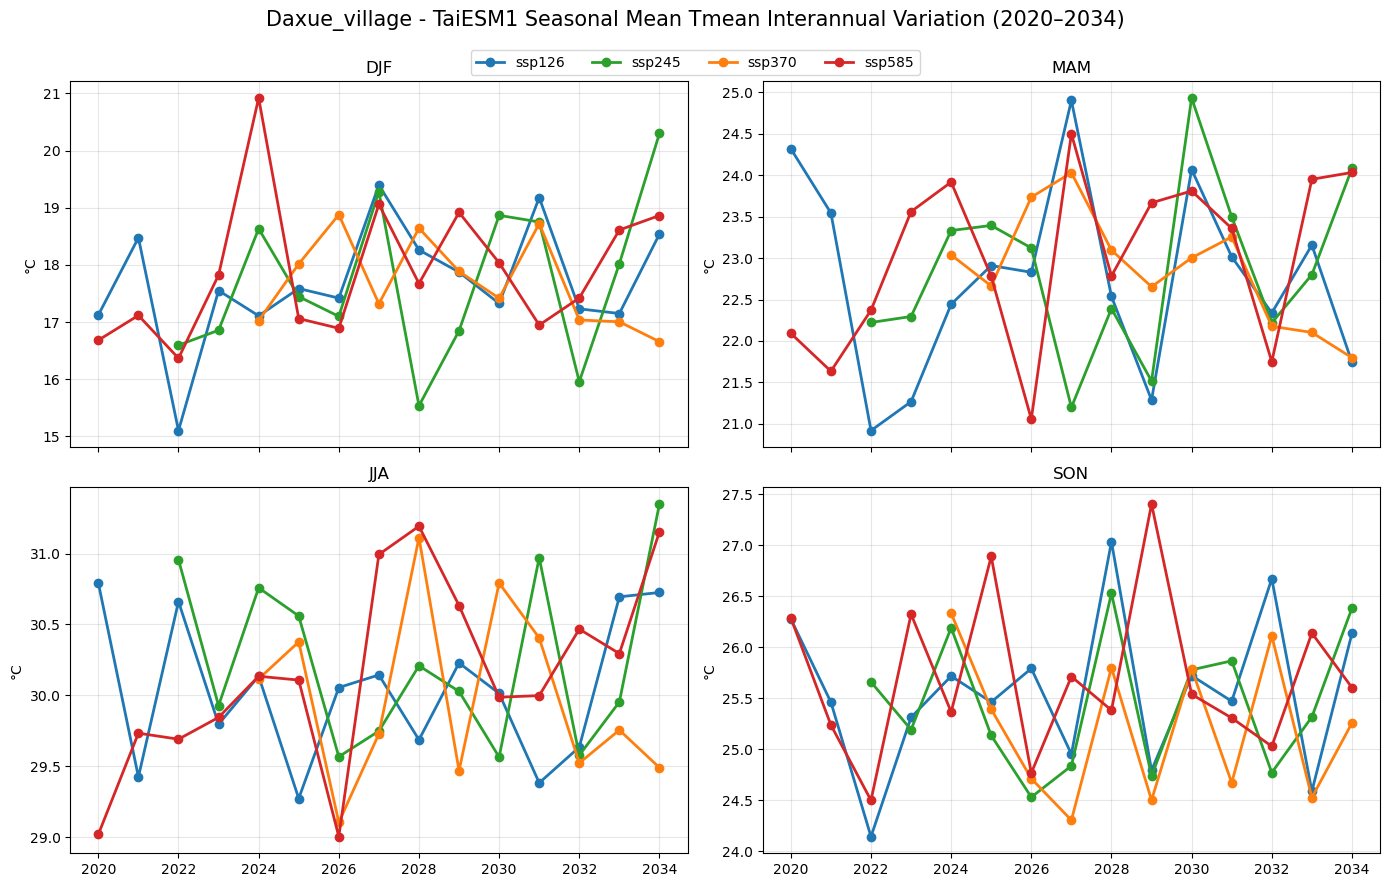

✅ Saved: \Users\user\OneDrive\桌面\Climate_project\程式作業\Daxue＿village\code\Daxue_village_TaiESM1_Seasonal_Days_with_Tmax_over_31C_Interannual_Variation_2020_2034.png


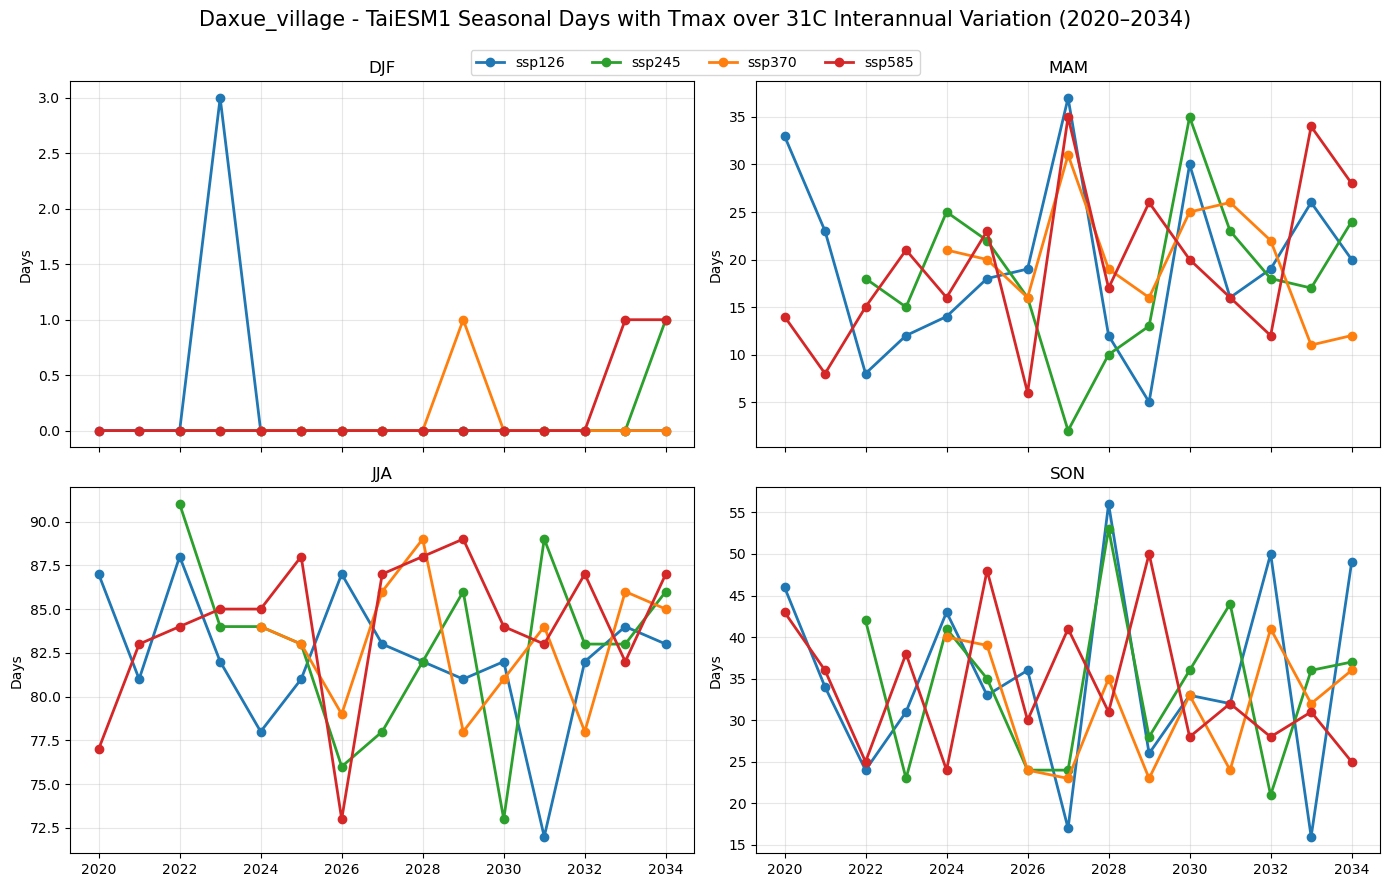

✅ Saved: \Users\user\OneDrive\桌面\Climate_project\程式作業\Daxue＿village\code\Daxue_village_TaiESM1_Seasonal_Days_with_Tmin_below_15.9C_Interannual_Variation_2020_2034.png


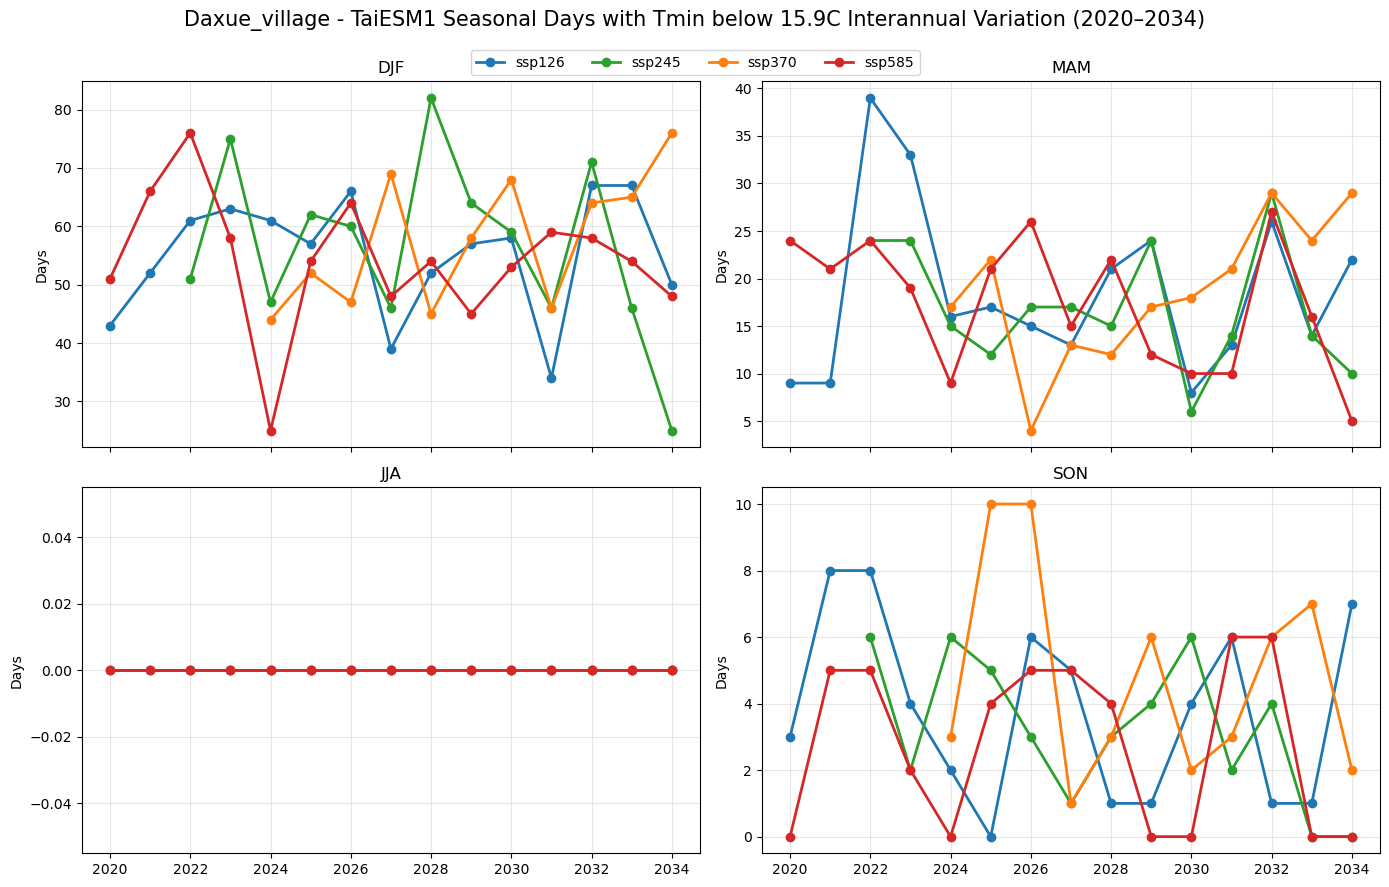

In [78]:
# 1. 季平均溫：看整體適生性
plot_seasonal_interannual_timeseries(
    seasonal_results, "tmean_seasonal_mean",
    "Seasonal Mean Tmean Interannual Variation", "°C",
    model_name, save_path
)

# 2. Tmax > 31°C：看最適生長窗口
plot_seasonal_interannual_timeseries(
    seasonal_results, "tmax_gt31_days",
    "Seasonal Days with Tmax over 31C Interannual Variation", "Days",
    model_name, save_path
)

# 3. Tmin < 15.9°C：看越冬屏障
plot_seasonal_interannual_timeseries(
    seasonal_results, "tmin_lt15_9_days",
    "Seasonal Days with Tmin below 15.9C Interannual Variation", "Days",
    model_name, save_path
)

✅ Saved: \Users\user\OneDrive\桌面\Climate_project\程式作業\Daxue＿village\code\Daxue_village_TaiESM1_Seasonal_Days_with_Tmax_over_31C_Interannual_Variation_2020_2034.png


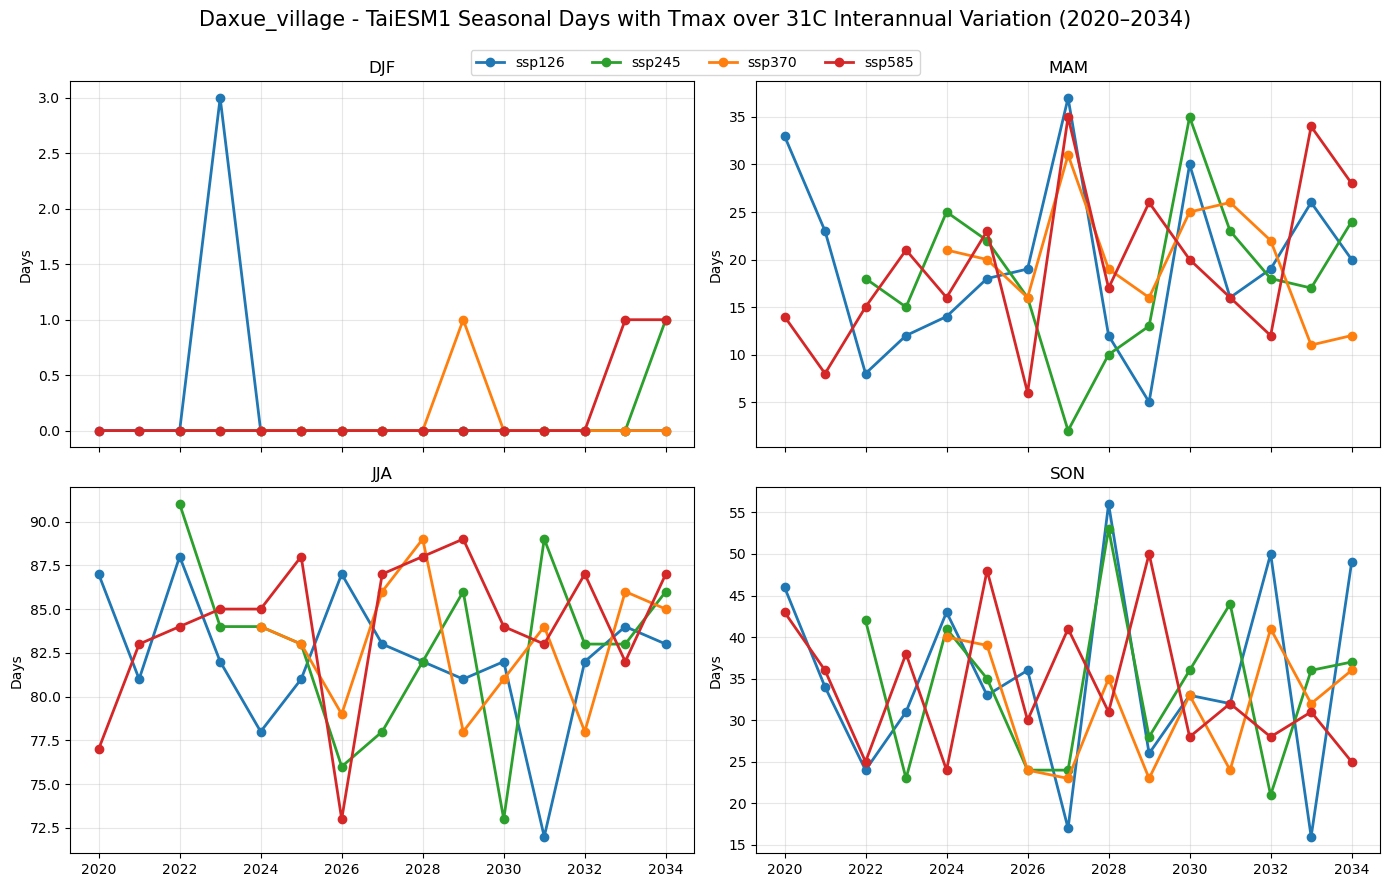

In [79]:
plot_seasonal_interannual_timeseries(
    seasonal_results=seasonal_results,
    metric="tmax_gt31_days",
    title="Seasonal Days with Tmax over 31C Interannual Variation",
    ylabel="Days",
    model_name=model_name,
    save_path=save_path
)

✅ Saved: \Users\user\OneDrive\桌面\Climate_project\程式作業\Daxue＿village\code\Daxue_village_TaiESM1_Seasonal_Days_with_Tmax_gteo_35C_Interannual_Variation_2020_2034.png


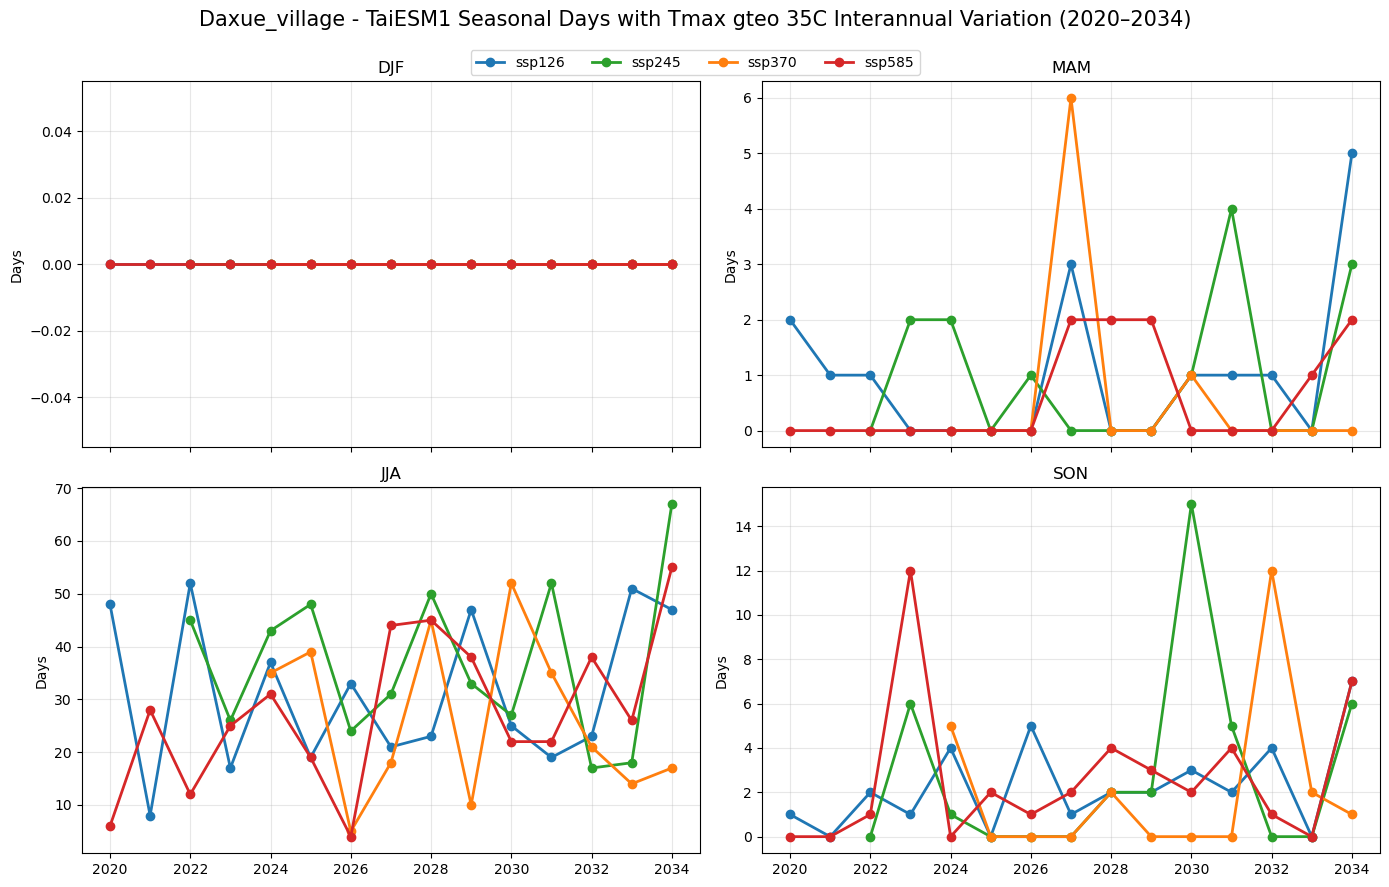

In [80]:
plot_seasonal_interannual_timeseries(
    seasonal_results=seasonal_results,
    metric="tmax_ge35_days",
    title="Seasonal Days with Tmax gteo 35C Interannual Variation",
    ylabel="Days",
    model_name=model_name,
    save_path=save_path
)

✅ Saved: \Users\user\OneDrive\桌面\Climate_project\程式作業\Daxue＿village\code\Daxue_village_TaiESM1_Seasonal_Days_with_Tmin_below_15.9C_Interannual_Variation_2020_2034.png


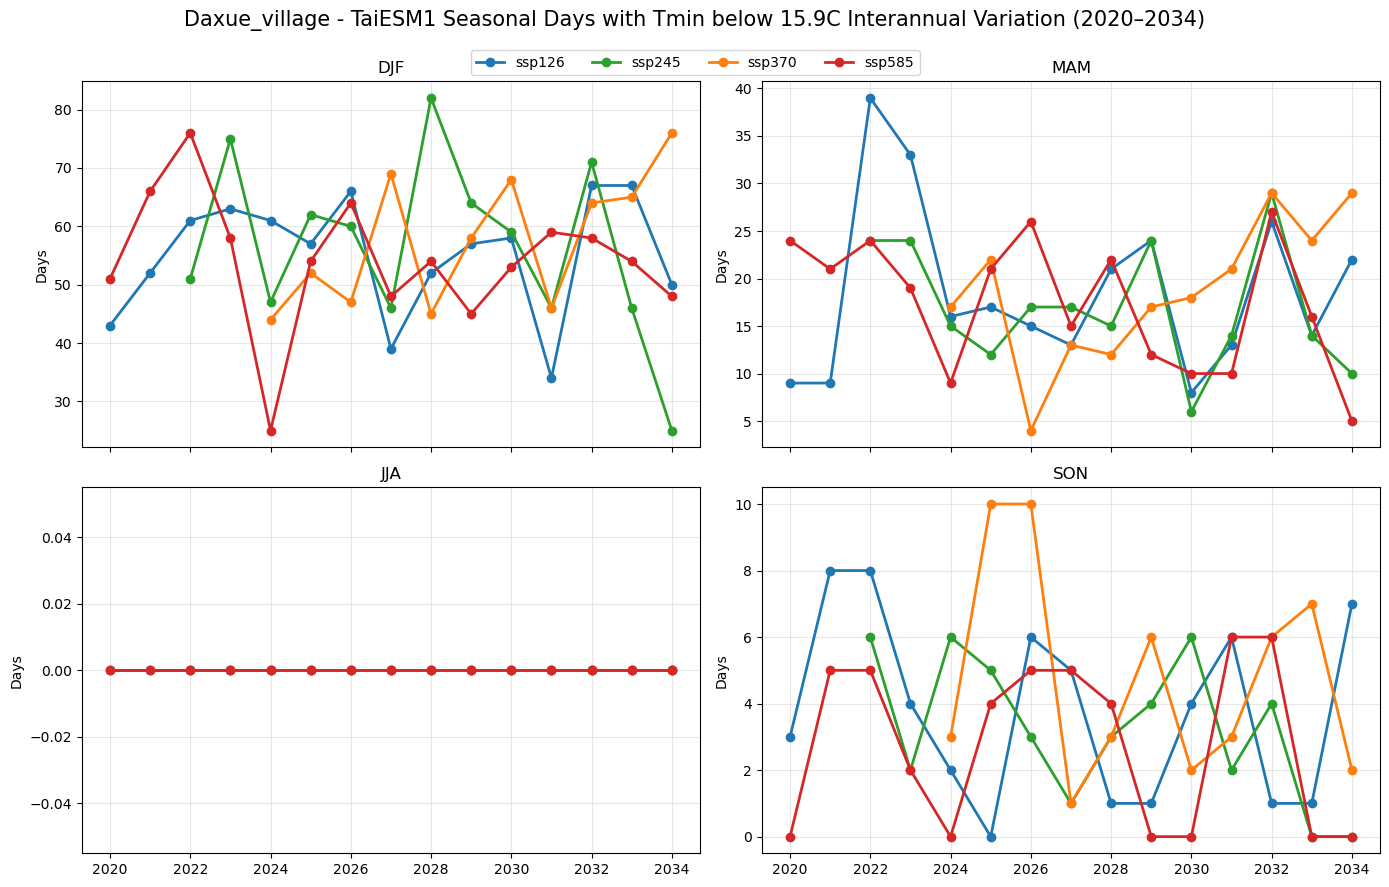

In [81]:
plot_seasonal_interannual_timeseries(
    seasonal_results=seasonal_results,
    metric="tmin_lt15_9_days",
    title="Seasonal Days with Tmin below 15.9C Interannual Variation",
    ylabel="Days",
    model_name=model_name,
    save_path=save_path
)